In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("nlp_posts.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2091 entries, 0 to 2090
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      2091 non-null   int64  
 1   Unnamed: 0        2091 non-null   int64  
 2   id                2091 non-null   object 
 3   title             2091 non-null   object 
 4   body              12 non-null     object 
 5   score             2091 non-null   int64  
 6   upvote_ratio      2091 non-null   float64
 7   num_comments      2091 non-null   int64  
 8   flair             2091 non-null   object 
 9   author            2091 non-null   object 
 10  url               2091 non-null   object 
 11  permalink         2091 non-null   object 
 12  created_utc       2091 non-null   object 
 13  category          2091 non-null   object 
 14  is_self_post      2091 non-null   bool   
 15  domain            2091 non-null   object 
 16  top_comments      1110 non-null   object 


In [4]:
df.shape

(2091, 26)

In [5]:
threshold = df["score"].quantile(0.75)
print(threshold)
df['Viral']=(df['score']>threshold).astype(int)

46179.0


In [6]:
df['Viral'].dtype

dtype('int64')

In [7]:
df['Viral'].value_counts()

Viral
0    1568
1     523
Name: count, dtype: int64

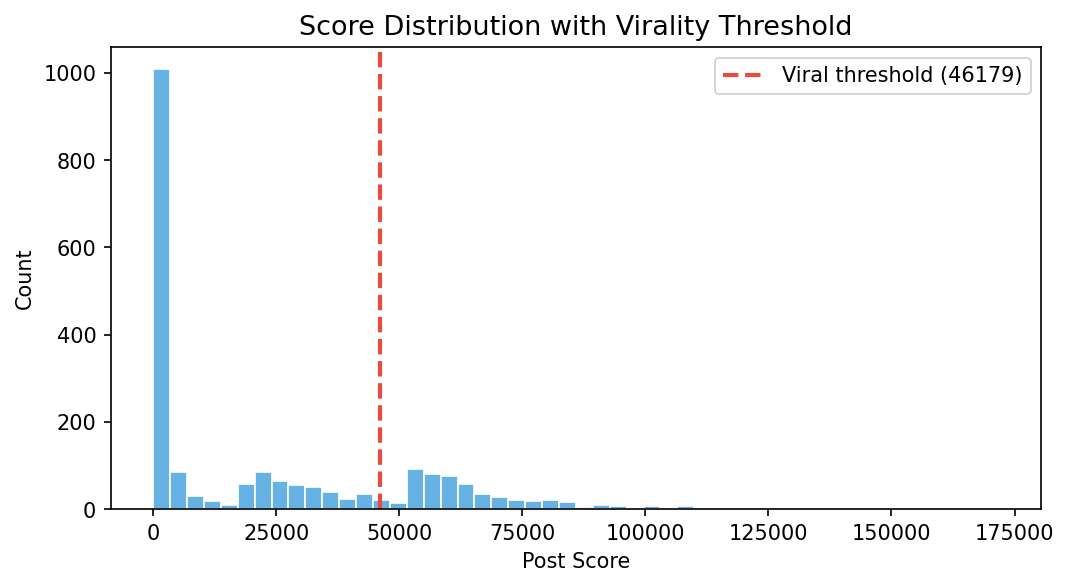

In [8]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=150)
sns.histplot(data=df, x="score", bins=50, color="#3498db", edgecolor="white", ax=ax)
ax.axvline(threshold, color="#e74c3c", linestyle="--", linewidth=2, label=f"Viral threshold ({threshold:.0f})")
ax.set_title("Score Distribution with Virality Threshold", fontsize=13)
ax.set_xlabel("Post Score")
ax.legend()

In [9]:
df = df.drop(columns=[col for col in df.columns if "Unnamed" in col])

In [10]:
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment_numeric"] = df["sentiment"].map(sentiment_map)

In [11]:
print(df[["sentiment", "sentiment_numeric", "confidence"]].head(20))

   sentiment  sentiment_numeric  confidence
0   negative                 -1      0.5265
1   negative                 -1      0.6667
2   negative                 -1      0.6376
3    neutral                  0      0.5808
4   negative                 -1      0.8899
5   negative                 -1      0.8146
6   negative                 -1      0.8778
7   negative                 -1      0.8693
8    neutral                  0      0.5175
9    neutral                  0      0.4442
10  negative                 -1      0.5865
11  negative                 -1      0.7082
12  positive                  1      0.6180
13  negative                 -1      0.6364
14  negative                 -1      0.8183
15  negative                 -1      0.7793
16   neutral                  0      0.4722
17  negative                 -1      0.8290
18  negative                 -1      0.9057
19  negative                 -1      0.8874


In [12]:
df["title_length"] = df["title"].fillna("").str.len()
df["title_word_count"] = df["title"].fillna("").str.split().str.len()
df["title_has_number"] = df["title"].fillna("").str.contains(r'\d').astype(int)
df["title_has_question"] =df["title"].fillna("").str.contains(r'\?').astype(int)
df["title_has_exclaim"] = df["title"].fillna("").str.contains(r'\!').astype(int)
df["has_comments_text"]= (df["top_comments"].fillna("").str.len() > 5).astype(int)

<Axes: xlabel='hour', ylabel='Count'>

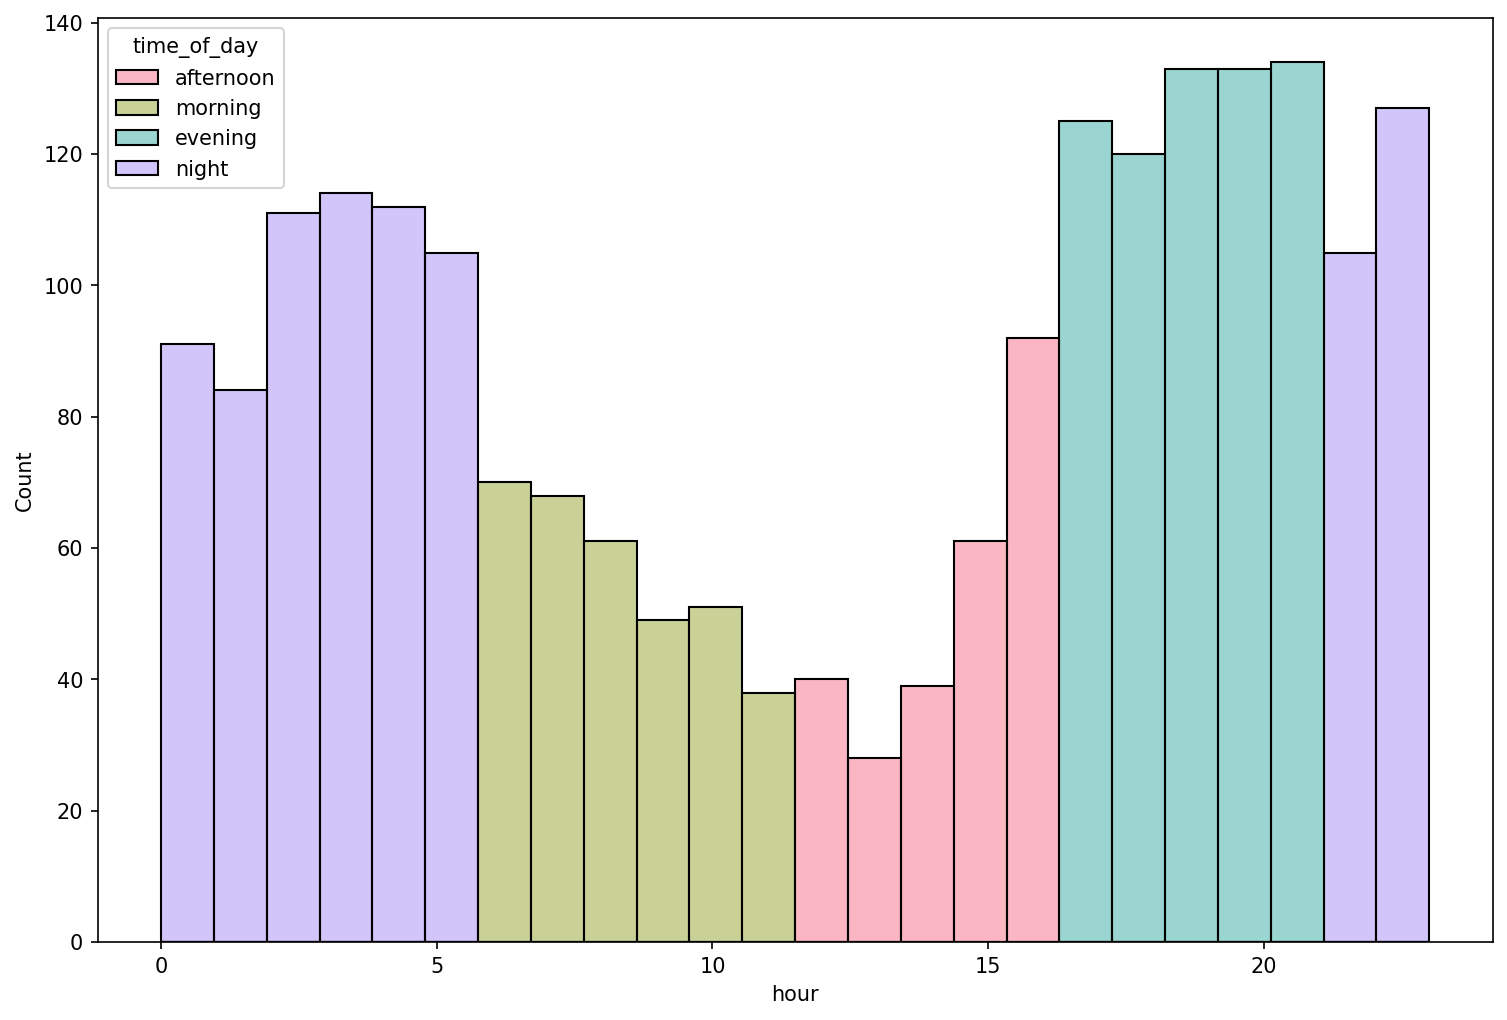

In [13]:
df["created_utc"] = pd.to_datetime(df["created_utc"])
df["hour"] = df["created_utc"].dt.hour
df["day_of_week"] = df["created_utc"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_peak_hour"] = df["hour"].between(8,22).astype(int)
def time_bucket(hour):
    if 6 <= hour < 12:   return "morning"
    elif 12 <= hour < 17: return "afternoon"
    elif 17 <= hour < 22: return "evening"
    else:                 return "night"

df["time_of_day"] = df["hour"].apply(time_bucket)
time_dummies = pd.get_dummies(df["time_of_day"], prefix="time")
plt.figure(figsize=(12,8),dpi=150)
sns.histplot(data=df,x="hour",hue="time_of_day",palette='husl',alpha=0.5,bins=24)


In [14]:
df = df.rename(columns={
    "Dominant_topics":  "dominant_topic",
    "topic_confidance": "topic_confidence",
    "Topic_labels":     "topic_label"
})
topic_dummies = pd.get_dummies(df["dominant_topic"], prefix="topic")
df["has_org_mention"]    = (df["orgs"].fillna("").str.len() > 0).astype(int)
df["org_mention_count"]  = df["orgs"].fillna("").str.split(" | ").apply(
                               lambda x: len([i for i in x if i.strip()])
                           )
df["has_person_mention"] = (df["persons"].fillna("").str.len() > 0).astype(int)

In [15]:
df.to_csv("feature_engineered_posts.csv")